# Sinarmas Land — Data Analysis

> **Capstone Project | IPL Billing, Payment Compliance, Data Quality & Utility Anomalies**

Notebook ini disusun sebagai alur analisis end-to-end: **Business Understanding → Data Understanding → Data Cleaning & Validation → EDA → Business Analysis → Insight & Recommendation**.

### Cara membaca notebook
Setiap tahap dijelaskan dengan tiga pertanyaan sederhana:
1. **Apa yang dilakukan?** — proses atau teknik analisis yang digunakan.
2. **Mengapa dilakukan?** — alasan teknis dan kaitannya dengan masalah bisnis.
3. **Apa maknanya?** — interpretasi hasil yang dapat dibawa ke presentasi atau rekomendasi bisnis.

> **Catatan privasi:** Output notebook publik tidak menampilkan nomor kontak, nama pemilik, atau identifier transaksi secara detail. Dataset mentah tidak disertakan dalam repository publik.


## Business Understanding

### Mengapa analisis ini dilakukan?

Sinar Mas Land mengembangkan kawasan *township* dan berbagai properti yang membutuhkan pengelolaan kawasan secara berkelanjutan. Dalam konteks *estate management*, data **Iuran Pemeliharaan Lingkungan (IPL)** menjadi penting karena berkaitan dengan kepatuhan pembayaran penghuni, arus pendapatan yang tertunda, serta kualitas data operasional.

Business case ini memanfaatkan tiga sumber data utama—**cluster, unit/properti, dan billing IPL**—untuk mencari pola tunggakan, masalah kelengkapan data, ketidakkonsistenan metode pembayaran, anomali tanggal transaksi, dan kejanggalan penggunaan air.

Dengan demikian, analisis tidak hanya bertujuan mengetahui kondisi data, tetapi juga mengubah temuan data menjadi **informasi yang dapat membantu prioritas collection, perbaikan kualitas data, dan pengawasan sistem billing**.



## Pernyataan Masalah

Berdasarkan business case Sinarmas Land, fokus analisis adalah:

1. Bagaimana rasio tunggakan berdasarkan township/cluster dan apakah tunggakan banyak berasal dari unit vacant?
2. Berapa estimasi pendapatan yang tertunda dari tagihan yang belum lunas, khususnya tunggakan berkelanjutan?
3. Seberapa tidak terstandardisasi pencatatan `payment_method`?
4. Berapa banyak data pemilik yang tidak memiliki `contact_number`?
5. Apakah terdapat logical error berupa pembayaran **Paid** sebelum `handover_date`?
6. Apakah terdapat anomali ekstrem pada `water_usage_m3`?

### Cara membaca masalah bisnis
Setiap pertanyaan di bawah akan diterjemahkan menjadi metrik atau analisis yang dapat dihitung dari dataset. Dengan pendekatan ini, hasil akhir tidak berhenti pada angka, tetapi menjawab **pertanyaan bisnis yang spesifik**.


## Data

Terdapat tiga dataset:

- `sml_clusters.csv` — dimensi cluster/township.
- `sml_units.csv` — dimensi unit/properti.
- `sml_ipl_billings.csv` — fakta tagihan bulanan.

Relasi utama:

`clusters (cluster_id) → units (cluster_id) → billings (unit_id)`

### Relasi antar dataset
Ketiga dataset membentuk hubungan berjenjang: **cluster → unit → billing**. `cluster_id` menghubungkan unit dengan cluster, sedangkan `unit_id` menghubungkan billing dengan unit. Relasi ini perlu divalidasi sebelum proses *merge* agar analisis tidak menggunakan referensi yang putus atau tidak valid.


### Setup Analisis

Cell ini menyiapkan library yang digunakan sepanjang notebook. Pandas digunakan untuk manipulasi data, NumPy untuk operasi numerik, Matplotlib/Seaborn untuk visualisasi, dan SciPy untuk pengujian statistik. Pengaturan tampilan Pandas diletakkan di awal agar tabel yang ditampilkan konsisten dan mudah dibaca.

**Output yang diharapkan:** environment analisis siap digunakan sebelum dataset dimuat.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import chi2_contingency

import warnings
warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")


### Memuat Dataset

Tiga dataset dibaca secara terpisah karena masing-masing memiliki fungsi berbeda: **clusters** sebagai informasi wilayah/cluster, **units** sebagai informasi properti dan owner, serta **billings** sebagai transaksi tagihan IPL.

Pada tahap ini kita belum melakukan penggabungan. Tujuannya agar struktur dan kualitas masing-masing sumber dapat diperiksa terlebih dahulu.


In [2]:
clusters = pd.read_csv("sml_clusters.csv")
units = pd.read_csv("sml_units.csv")
billings = pd.read_csv("sml_ipl_billings.csv")

display(clusters.head(), units.head(), billings.head())

,cluster_id,township_name,cluster_category
0,CLS-SML-001,BSD City,Middle Residential
1,CLS-SML-002,Grand Wisata,Middle Residential
2,CLS-SML-003,Kota Wisata,Middle Residential
3,CLS-SML-004,Grand Wisata,Middle Residential
4,CLS-SML-005,Grand Wisata,Commercial Ruko


,unit_id,cluster_id,owner_name,contact_number,is_vacant,handover_date
0,UNT-00001,CLS-SML-096,Pemilik Properti 0,"8,120,452,150.00",False,2021-10-24
1,UNT-00002,CLS-SML-075,Pemilik Properti 1,"8,117,280,852.00",True,2022-05-13
2,UNT-00003,CLS-SML-012,Pemilik Properti 2,"8,164,339,053.00",True,2022-06-19
3,UNT-00004,CLS-SML-035,Pemilik Properti 3,"8,180,059,262.00",False,2022-01-24
4,UNT-00005,CLS-SML-054,Pemilik Properti 4,"8,166,340,005.00",False,2020-12-30


,invoice_id,unit_id,billing_month,water_usage_m3,ipl_base_fee,total_amount,payment_status,payment_method,payment_date
0,INV-IPL-00000001,UNT-17116,2023-08,48.00,850000,"1,210,000.00",Paid,Cash,2023-08-17
1,INV-IPL-00000002,UNT-09718,2023-10,26.00,500000,"695,000.00",Unpaid,NaN,NaN
2,INV-IPL-00000003,UNT-20344,2024-06,1.00,350000,"357,500.00",Paid,Cash,2024-06-25
3,INV-IPL-00000004,UNT-23600,2024-02,17.00,850000,"977,500.00",Paid,KAS,2024-02-06
4,INV-IPL-00000005,UNT-12569,2023-05,1.00,850000,"857,500.00",Paid,toped,2023-05-08


Dataset terdiri dari tiga **tabel**: **clusters, units, dan IPL Billings** 
1. `sml_clusters.csv` -- Dimensi Cluster/Kawasan yang terdiri dari tiga kolom yaitu: 
   - `cluster_id` = Kode unik yang mengidentifikasi setiap cluster/kawasan. Digunakan sebagai key untuk menghubungkan data cluster dengan data unit 
   - `township_name` = Nama township/kota mandiri tempat cluster berada, seperti **BSD City, Kota Wisata, Grand Wisata, NavaPark, dan Deltamas**
   - `cluster_category` = Kategori/segmen pasar dari cluster, yaitu **Middle Residential, Premium Residential, Commercial Ruko, dan Industrial/Commercial**

2. `sml_units.csv` -- Dimensi Unit/Properti yang terdiri dari enam kolom yaitu:
   - `unit_id` = ID unik yang mengidentifikasi setiap unit properti, seperti rumah/ruko
   - `cluster_id`= ID cluster tempat unit berada. Digunakan untuk menghubungkan unit dengan informasi cluster pada `sml_clusters.csv`
   - `owner_name` = Nama pemilik unit properti. Digunakan sebagai identitas pemilik dan tidak menjadi variabel utama dalam analisis statistik
   - `contact_number` = Nomor telepon yang dapat digunakan untuk kebutuhan komunikasi dan proses collection. Missing value pada kolom ini menjadi salah satu indikator kualitas data
   - `is_vacant`= Menunjukkan apakah unit sedang kosong/tidak dihuni (`True`) atau dihuni (`False`). Digunakan untuk menganalisis hubungan status hunian dengan pembayaran
   - `handover_date` = Tanggal serah terima unit dari developer kepada pemilik. Digunakan sebagai acuan untuk mendeteksi pembayaran yang terjadi sebelum unit diserahterimakan

3. `sml_ipl_billings.csv` -- Fakta Tagihan Bulanan yang terdiri dari sembilan kolom yaitu:
   - `invoice_id` = ID unik untuk setiap invoice/tagihan bulanan
   - `unit_id` = ID unik yang dikenakan tagihan. Digunakan untuk menghubungkan invoice dengan informasi unit pada `sml_units.csv`
   - `billing_month` = Periode bulan tagihan dalam format `YYYY-MM`. Menunjukkan bulan yang menjadi periode penagihan 
   - `water_usage_m3` = Jumlah penggunaan air dalam satuan meter kubik. Digunakan untuk menganalisis pola penggunaan air dan mendeteksi nilai yang tidak wajar
   - `ipl_base_fee` = **Biaya Iuran Pemeliharaan Lingkungan (IPL)**, yang berkaitan dengan biaya pemeliharaan keamanan, kebersihan, dan lingkungan kawasan
   - `total_amount` = Total nominal invoice yang harus dibayarkan. 
   - `payment_status` = Status pembayaran invoice: `Paid`, `Unpaid`, atau `Overdue`. Digunakan untuk menentukan apakah invoice sudah dibayar atau masih menjadi outstanding
   - `payment_method` = Metode pembayaran yang tercatat pada sistem, misalnya **BCA Virtual Account, Tokopedia, Cash, Credit Card, dan yang lainnya**
   - `payment_date` = Tanggal ketika pembayaran invoice tercatat. Dapat kosong/ `NaT`, terutama ketika invoice belum dibayar

## Data Understanding and Cleaning

Tahap ini digunakan untuk memahami struktur dataset sekaligus menemukan anomali yang perlu ditangani sebelum analisis bisnis dilakukan.

### 1. Ukuran dan Struktur Dataset

**Tujuan:** mengetahui skala data dan peran masing-masing dataset sebelum melakukan pembersihan. Ukuran baris membantu memahami volume observasi, sedangkan jumlah kolom membantu mengenali informasi yang tersedia untuk analisis.


### Mengecek Ukuran dan Struktur

Setelah data dimuat, kita memeriksa jumlah baris, jumlah kolom, dan tipe data setiap dataset. Langkah ini membantu memastikan tidak ada dataset yang salah terbaca sebelum masuk ke proses cleaning.


In [3]:
for name, df in {
    "clusters": clusters,
    "units": units,
    "billings": billings
}.items():
    print(f"{name.upper():<10} : {df.shape[0]:,} rows x {df.shape[1]} columns")

CLUSTERS   : 100 rows x 3 columns
UNITS      : 25,000 rows x 6 columns
BILLINGS   : 300,000 rows x 9 columns


### Mengecek Ukuran dan Struktur

Setelah data dimuat, kita memeriksa jumlah baris, jumlah kolom, dan tipe data setiap dataset. Langkah ini membantu memastikan tidak ada dataset yang salah terbaca sebelum masuk ke proses cleaning.


In [4]:
for name, df in {
    "clusters": clusters,
    "units": units,
    "billings": billings
}.items():
    print(f"\n===== {name.upper()} =====")
    display(df.info())


===== CLUSTERS =====
<class 'pandas.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 3 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   cluster_id        100 non-null    str  
 1   township_name     100 non-null    str  
 2   cluster_category  100 non-null    str  
dtypes: str(3)
memory usage: 6.2 KB


None


===== UNITS =====
<class 'pandas.DataFrame'>
RangeIndex: 25000 entries, 0 to 24999
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   unit_id         25000 non-null  str    
 1   cluster_id      25000 non-null  str    
 2   owner_name      25000 non-null  str    
 3   contact_number  20000 non-null  float64
 4   is_vacant       25000 non-null  bool   
 5   handover_date   25000 non-null  str    
dtypes: bool(1), float64(1), str(4)
memory usage: 2.2 MB


None


===== BILLINGS =====
<class 'pandas.DataFrame'>
RangeIndex: 300000 entries, 0 to 299999
Data columns (total 9 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   invoice_id      300000 non-null  str    
 1   unit_id         300000 non-null  str    
 2   billing_month   300000 non-null  str    
 3   water_usage_m3  300000 non-null  float64
 4   ipl_base_fee    300000 non-null  int64  
 5   total_amount    300000 non-null  float64
 6   payment_status  300000 non-null  str    
 7   payment_method  209722 non-null  str    
 8   payment_date    209722 non-null  str    
dtypes: float64(2), int64(1), str(6)
memory usage: 34.6 MB


None

### 2. Statistik Deskriptif dan Unique Value

**Tujuan:** melihat karakteristik dasar setiap variabel. Statistik deskriptif membantu menemukan nilai yang tidak wajar, sedangkan jumlah nilai unik membantu memahami apakah sebuah kolom berperan sebagai ID, kategori, tanggal, atau variabel numerik.


### Statistik Deskriptif

Statistik deskriptif digunakan untuk memperoleh gambaran awal mengenai variabel numerik dan kategorikal. Pada tahap ini kita mencari sinyal awal seperti rentang nilai yang tidak wajar, variasi yang terlalu besar, atau kategori yang tidak sesuai konteks.


In [5]:
display(clusters.describe(include="all"))
display(units.describe(include="all"))
display(billings.describe(include="all"))

,cluster_id,township_name,cluster_category
count,100,100,100
unique,100,5,4
top,CLS-SML-001,BSD City,Middle Residential
freq,1,33,61


,unit_id,cluster_id,owner_name,contact_number,is_vacant,handover_date
count,25000,25000,25000,"20,000.00",25000,25000
unique,25000,100,25000,NaN,2,1000
top,UNT-00001,CLS-SML-099,Pemilik Properti 0,NaN,False,2021-05-13
freq,1,304,1,NaN,18822,43
mean,NaN,NaN,NaN,"8,155,307,650.92",NaN,NaN
std,NaN,NaN,NaN,"25,957,292.84",NaN,NaN
min,NaN,NaN,NaN,"8,110,012,099.00",NaN,NaN
25%,NaN,NaN,NaN,"8,132,963,781.75",NaN,NaN
50%,NaN,NaN,NaN,"8,155,499,438.50",NaN,NaN
75%,NaN,NaN,NaN,"8,177,874,522.25",NaN,NaN


,invoice_id,unit_id,billing_month,water_usage_m3,ipl_base_fee,total_amount,payment_status,payment_method,payment_date
count,300000,300000,300000,"300,000.00","300,000.00","300,000.00",300000,209722,209722
unique,300000,25000,69,NaN,NaN,NaN,3,9,1894
top,INV-IPL-00000001,UNT-20096,2024-12,NaN,NaN,NaN,Paid,toped,2023-12-08
freq,1,29,12477,NaN,NaN,NaN,209722,23449,369
mean,NaN,NaN,NaN,71.50,"799,688.17","1,335,930.29",NaN,NaN,NaN
std,NaN,NaN,NaN,699.43,"442,724.35","5,265,803.26",NaN,NaN,NaN
min,NaN,NaN,NaN,-15.00,"350,000.00","237,500.00",NaN,NaN,NaN
25%,NaN,NaN,NaN,2.00,"500,000.00","597,500.00",NaN,NaN,NaN
50%,NaN,NaN,NaN,23.00,"500,000.00","850,000.00",NaN,NaN,NaN
75%,NaN,NaN,NaN,36.00,"850,000.00","1,500,000.00",NaN,NaN,NaN


### Ringkasan Nilai Unik

Jumlah nilai unik membantu mengidentifikasi karakteristik kolom. Contohnya, ID seharusnya memiliki nilai unik yang tinggi, sedangkan variabel kategori seperti `payment_status` seharusnya memiliki jumlah kategori yang relatif terbatas.


In [6]:
def unique_summary(df):
    rows = []
    for col in df.columns:
        rows.append({
            "Column Name": col,
            "Data Type": str(df[col].dtype),
            "Number of Unique": df[col].nunique(dropna=True),
            "Missing": df[col].isna().sum(),
            "Missing (%)": df[col].isna().mean() * 100,
            "Sample Unique": df[col].dropna().unique()[:10].tolist()
        })
    return pd.DataFrame(rows)

display(unique_summary(clusters))
display(unique_summary(units))
display(unique_summary(billings))

,Column Name,Data Type,Number of Unique,Missing,Missing (%),Sample Unique
0,cluster_id,str,100,0,0.00,"[CLS-SML-001, CLS-SML-002, CLS-SML-003, CLS-SM..."
1,township_name,str,5,0,0.00,"[BSD City, Grand Wisata, Kota Wisata, NavaPark..."
2,cluster_category,str,4,0,0.00,"[Middle Residential, Commercial Ruko, Premium ..."


,Column Name,Data Type,Number of Unique,Missing,Missing (%),Sample Unique
0,unit_id,str,25000,0,0.00,"[UNT-00001, UNT-00002, UNT-00003, UNT-00004, U..."
1,cluster_id,str,100,0,0.00,"[CLS-SML-096, CLS-SML-075, CLS-SML-012, CLS-SM..."
2,owner_name,str,25000,0,0.00,"[Pemilik Properti 0, Pemilik Properti 1, Pemil..."
3,contact_number,float64,19998,5000,20.00,"[8120452150.0, 8117280852.0, 8164339053.0, 818..."
4,is_vacant,bool,2,0,0.00,"[False, True]"
5,handover_date,str,1000,0,0.00,"[2021-10-24, 2022-05-13, 2022-06-19, 2022-01-2..."


,Column Name,Data Type,Number of Unique,Missing,Missing (%),Sample Unique
0,invoice_id,str,300000,0,0.00,"[INV-IPL-00000001, INV-IPL-00000002, INV-IPL-0..."
1,unit_id,str,25000,0,0.00,"[UNT-17116, UNT-09718, UNT-20344, UNT-23600, U..."
2,billing_month,str,69,0,0.00,"[2023-08, 2023-10, 2024-06, 2024-02, 2023-05, ..."
3,water_usage_m3,float64,45,0,0.00,"[48.0, 26.0, 1.0, 17.0, 21.0, 16.0, 0.0, 18.0,..."
4,ipl_base_fee,int64,4,0,0.00,"[850000, 500000, 350000, 1500000]"
5,total_amount,float64,157,0,0.00,"[1210000.0, 695000.0, 357500.0, 977500.0, 8575..."
6,payment_status,str,3,0,0.00,"[Paid, Unpaid, Overdue]"
7,payment_method,str,9,90278,30.09,"[Cash, KAS, toped, BCA Virtual Account, Tokope..."
8,payment_date,str,1894,90278,30.09,"[2023-08-17, 2024-06-25, 2024-02-06, 2023-05-0..."


### 3. Duplicate Data

ID pada tabel dimensi dan fakta seharusnya unik sesuai dictionary dataset. Duplicate dicek sebelum melakukan transformasi.

**Tujuan:** memastikan tidak ada observasi atau identifier yang tercatat lebih dari satu kali. Duplikasi pada `cluster_id`, `unit_id`, atau `invoice_id` dapat menyebabkan penghitungan unit/invoice menjadi lebih besar dari kondisi sebenarnya.


### Pemeriksaan Duplikasi

Duplikasi diperiksa pada dua level: **baris secara keseluruhan** dan **identifier utama**. Hal ini penting karena satu invoice yang terduplikasi dapat menggandakan nilai tagihan dan mengubah hasil agregasi.


In [7]:
print("Duplicate rows:")
print("clusters :", clusters.duplicated().sum())
print("units    :", units.duplicated().sum())
print("billings :", billings.duplicated().sum())

print("\nDuplicate ID:")
print("cluster_id :", clusters["cluster_id"].duplicated().sum())
print("unit_id    :", units["unit_id"].duplicated().sum())
print("invoice_id :", billings["invoice_id"].duplicated().sum())

Duplicate rows:
clusters : 0
units    : 0
billings : 0

Duplicate ID:
cluster_id : 0
unit_id    : 0
invoice_id : 0


### 4. Missing Value

**Tujuan:** mengukur kelengkapan data sebelum menentukan strategi penanganan. Missing value tidak otomatis berarti data harus dihapus; tindakan harus mengikuti arti bisnis dari kolom tersebut.


### Pemeriksaan Missing Value

Missing value perlu diperiksa untuk mengetahui apakah terdapat informasi
yang tidak tersedia pada dataset. Missing value pada kolom tertentu dapat
mempengaruhi hasil analisis, terutama pada variabel yang digunakan untuk
mengukur kepatuhan pembayaran atau kualitas data pelanggan.

Pemeriksaan dilakukan pada seluruh dataset sebelum menentukan tindakan
penanganan yang sesuai.

### Mengukur Missing Value

Kita menghitung jumlah dan persentase missing untuk setiap kolom. Persentase digunakan agar kelengkapan data dapat dibandingkan meskipun ukuran dataset berbeda.


In [8]:
missing_summary = []
for name, df in {"clusters": clusters, "units": units, "billings": billings}.items():
    for col in df.columns:
        missing_summary.append({
            "Dataset": name,
            "Column": col,
            "Missing": df[col].isna().sum(),
            "Missing (%)": df[col].isna().mean() * 100
        })

missing_df = pd.DataFrame(missing_summary)
display(missing_df[missing_df["Missing"] > 0].sort_values("Missing (%)", ascending=False))

,Dataset,Column,Missing,Missing (%)
16,billings,payment_method,90278,30.09
17,billings,payment_date,90278,30.09
6,units,contact_number,5000,20.00


### Interpretasi

Ditemukan missing value pada beberapa kolom. Missing value tidak langsung
dihapus karena setiap kolom memiliki makna bisnis yang berbeda. Oleh karena
itu, penanganan dilakukan berdasarkan fungsi dan konteks masing-masing
variabel.

#### `contact_number`

`contact_number` terbaca sebagai numeric karena nomor telepon pada data tidak menyimpan angka `0` di depan. Nomor telepon bukan variabel untuk operasi matematika, sehingga lebih tepat diperlakukan sebagai string.

Missing value tidak diisi dengan angka/fiktif karena nomor telepon yang tidak tersedia tidak dapat disimpulkan dari kolom lain.

### Perbaikan Format Contact Number

Nomor telepon seharusnya diperlakukan sebagai identifier, bukan angka untuk operasi matematika. Karena itu, kolom diubah menjadi string dan angka nol di depan dipertahankan melalui `zfill` pada data yang tersedia.


In [9]:
# Simpan sebagai string dan tambahkan leading zero pada nomor yang tersedia.
units["contact_number"] = (
    units["contact_number"]
    .astype("Int64")
    .astype("string")
    .str.zfill(11)
)

missing_contact = units["contact_number"].isna().sum()
print(f"Missing contact number: {missing_contact:,}")
print(f"Persentase missing: {missing_contact / len(units) * 100:.2f}%")
print(f"Data type setelah pembersihan: {units['contact_number'].dtype}")
# Nilai kontak tidak ditampilkan pada notebook publik.

Missing contact number: 5000


0    08120452150
1    08117280852
2    08164339053
3    08180059262
4    08166340005
Name: contact_number, dtype: string

#### `payment_method` dan `payment_date`

Missing pada dua kolom ini perlu dibaca berdasarkan `payment_status`.

- `Paid` seharusnya mempunyai informasi pembayaran.
- `Unpaid`/`Overdue` secara logis tidak membutuhkan tanggal pembayaran yang sudah terjadi.
- `payment_method` memiliki beberapa variasi penamaan untuk metode yang sama.

In [10]:
display(
    billings.groupby("payment_status")[["payment_method", "payment_date"]]
    .agg(lambda s: s.isna().sum())
)

,payment_method,payment_date
payment_status,,
Overdue,52754,52754
Paid,0,0
Unpaid,37524,37524


### 5. Standardisasi `payment_method`

**Tujuan:** menyatukan variasi penulisan metode pembayaran yang sebenarnya merujuk pada kategori yang sama. Standardisasi penting agar frekuensi metode pembayaran tidak terpecah menjadi beberapa kategori hanya karena perbedaan kapitalisasi atau singkatan.


### Standardisasi Payment Method

Kategori pembayaran memiliki beberapa variasi penulisan seperti singkatan, kapitalisasi, atau nama yang berbeda tetapi bermakna sama. Kita membuat kolom baru `payment_method_clean` agar data asli tetap tersedia untuk audit, sementara analisis menggunakan kategori yang sudah distandardisasi.


In [11]:
billings["payment_method_clean"] = billings["payment_method"].replace({
    "toped": "Tokopedia",
    "Tokopedia": "Tokopedia",
    "KAS": "Cash",
    "Cash": "Cash",
    "cc": "Credit Card",
    "Credit Card": "Credit Card",
    "bca va": "BCA Virtual Account",
    "BCA Virtual Account": "BCA Virtual Account",
    "VA BCA": "BCA Virtual Account"
})

display(
    pd.DataFrame({
        "Before": billings["payment_method"].value_counts(dropna=False),
    })
)

print("\nAfter standardization:")
display(billings["payment_method_clean"].value_counts(dropna=False))

,Before
payment_method,
NaN,90278
toped,23449
KAS,23438
Cash,23370
cc,23302
Credit Card,23267
bca va,23242
Tokopedia,23238
BCA Virtual Account,23216



After standardization:


payment_method_clean
NaN                    90278
BCA Virtual Account    69658
Cash                   46808
Tokopedia              46687
Credit Card            46569
Name: count, dtype: int64

### 6. Konversi Tipe Data Tanggal

**Tujuan:** mengubah kolom tanggal menjadi format datetime agar dapat digunakan untuk perbandingan waktu, pengurutan, perhitungan periode, dan validasi kronologis.


### Konversi Kolom Tanggal

Kolom tanggal dikonversi menjadi tipe datetime. `billing_month` juga dibuat menjadi tanggal awal bulan agar dapat digunakan dalam analisis urutan waktu dan perhitungan streak tunggakan.


In [12]:
units["handover_date"] = pd.to_datetime(units["handover_date"], errors="coerce")

billings["billing_date"] = pd.to_datetime(
    billings["billing_month"] + "-01",
    errors="coerce"
)
billings["payment_date"] = pd.to_datetime(
    billings["payment_date"],
    errors="coerce"
)

print("Handover :", units["handover_date"].min(), "s/d", units["handover_date"].max())
print("Billing  :", billings["billing_date"].min(), "s/d", billings["billing_date"].max())
print("Payment  :", billings["payment_date"].min(), "s/d", billings["payment_date"].max())

Handover : 2020-01-01 00:00:00 s/d 2022-09-26 00:00:00
Billing  : 2018-01-01 00:00:00 s/d 2024-12-01 00:00:00
Payment  : 2018-01-07 00:00:00 s/d 2024-12-28 00:00:00


### 7. Validasi Relasi Antar Dataset

**Tujuan:** memastikan setiap referensi antar tabel valid sebelum data digabungkan. Kita mengecek apakah `unit_id` pada billing terdapat di tabel units dan apakah `cluster_id` pada units terdapat di tabel clusters.

Jika terdapat referensi yang tidak ditemukan, hasil *merge* dapat menghasilkan informasi unit/cluster yang kosong sehingga analisis berikutnya berisiko salah.


### Validasi Relasi Antar Dataset

Sebelum melakukan penggabungan (*merge*), perlu dipastikan bahwa setiap
`unit_id` yang terdapat pada data billing memiliki pasangan yang valid
pada dataset units.

Validasi ini dilakukan untuk menghindari adanya invoice yang merujuk
pada unit yang tidak terdaftar. Jika ditemukan data tersebut, hasil
analisis setelah proses merge dapat menjadi tidak akurat.

**Validasi yang dilakukan:**
- Memastikan setiap `unit_id` pada billing terdapat pada dataset units.
- Memastikan setiap `cluster_id` pada units terdapat pada dataset clusters.

In [13]:
print("Billing tanpa unit:", (~billings["unit_id"].isin(units["unit_id"])).sum())
print("Unit tanpa cluster:", (~units["cluster_id"].isin(clusters["cluster_id"])).sum())

Billing tanpa unit: 0
Unit tanpa cluster: 0


**Interpretasi:**

Hasil validasi menunjukkan bahwa seluruh `unit_id` pada data billing
memiliki referensi yang sesuai pada dataset units. Dengan demikian,
relasi antara data billing dan data unit dapat digunakan untuk proses
merge dan analisis selanjutnya.

### 8. Logical Error: Pembayaran Sebelum Handover

**Tujuan:** mendeteksi ketidakkonsistenan kronologis antara `payment_date` dan `handover_date`. Untuk invoice yang berstatus `Paid`, pembayaran yang tercatat jauh sebelum unit diserahterimakan merupakan sinyal yang perlu diperiksa lebih lanjut.


### Membentuk Analytical Dataset

Setelah kualitas data diperiksa, tiga dataset digabungkan menjadi satu tabel analitis. Billing menjadi titik awal karena satu baris merepresentasikan satu invoice, kemudian informasi unit dan cluster ditambahkan berdasarkan key yang telah divalidasi.

Selain atribut asli, kita membuat flag `paid_before_handover`, `water_negative`, `water_iqr_outlier`, `outstanding_amount`, dan `is_arrears` untuk mendukung analisis bisnis berikutnya.


In [14]:
df = (
    billings
    .merge(
        units[["unit_id", "cluster_id", "owner_name", "contact_number", "is_vacant", "handover_date"]],
        on="unit_id",
        how="left"
    )
    .merge(
        clusters,
        on="cluster_id",
        how="left"
    )
)

df["paid_before_handover"] = (
    (df["payment_status"] == "Paid") &
    df["payment_date"].notna() &
    df["handover_date"].notna() &
    (df["payment_date"] < df["handover_date"])
)

logical_error = df[df["paid_before_handover"]].copy()

print(f"Jumlah Paid sebelum handover: {len(logical_error):,}")
display(
    logical_error[
        ["billing_month", "payment_date", "handover_date",
         "payment_status", "total_amount", "township_name"]
    ].head(10)
)

Jumlah Paid sebelum handover: 6,291


,invoice_id,unit_id,billing_month,payment_date,handover_date,payment_status,total_amount,township_name
61,INV-IPL-00000062,UNT-20834,2020-05,2020-05-02,2021-06-06,Paid,"76,492,500.00",BSD City
90,INV-IPL-00000091,UNT-23534,2019-01,2019-01-28,2020-02-18,Paid,"627,500.00",BSD City
107,INV-IPL-00000108,UNT-20049,2020-04,2020-04-16,2021-05-30,Paid,"860,000.00",Kota Wisata
114,INV-IPL-00000115,UNT-21228,2021-04,2021-04-04,2022-09-05,Paid,"425,000.00",Kota Wisata
123,INV-IPL-00000124,UNT-01322,2019-02,2019-02-23,2020-12-12,Paid,"1,052,500.00",NavaPark
264,INV-IPL-00000265,UNT-10371,2020-10,2020-10-22,2022-01-29,Paid,"642,500.00",Deltamas
298,INV-IPL-00000299,UNT-11286,2019-11,2019-11-06,2021-10-13,Paid,"1,687,500.00",Grand Wisata
342,INV-IPL-00000343,UNT-19742,2018-08,2018-08-31,2020-01-08,Paid,"627,500.00",BSD City
355,INV-IPL-00000356,UNT-14833,2020-01,2020-01-20,2021-03-22,Paid,"545,000.00",Grand Wisata
481,INV-IPL-00000482,UNT-15591,2020-04,2020-04-03,2021-07-29,Paid,"1,037,500.00",Kota Wisata


**Keputusan cleaning:** logical error ini tidak dihapus dari dataset utama. Data tersebut justru merupakan temuan bisnis yang perlu dilaporkan karena mengindikasikan ketidakkonsistenan antara sistem billing dan status unit.

### 9. Outlier `water_usage_m3`

**Tujuan:** mengidentifikasi nilai penggunaan air yang secara statistik atau secara logika bisnis terlihat tidak wajar. Kita menggunakan dua sinyal: nilai negatif dan outlier berdasarkan IQR. Outlier ditandai terlebih dahulu agar dapat ditindaklanjuti tanpa menghilangkan bukti masalah data.


### Menandai Anomali Water Usage

IQR digunakan sebagai metode statistik untuk menandai nilai yang jauh dari distribusi utama. Nilai negatif ditandai terpisah karena secara logika penggunaan air tidak seharusnya bernilai negatif.



In [15]:
q1 = df["water_usage_m3"].quantile(0.25)
q3 = df["water_usage_m3"].quantile(0.75)
iqr = q3 - q1
upper_bound = q3 + 1.5 * iqr

df["water_negative"] = df["water_usage_m3"] < 0
df["water_iqr_outlier"] = df["water_usage_m3"] > upper_bound

print(f"Q1              : {q1:.2f}")
print(f"Q3              : {q3:.2f}")
print(f"IQR             : {iqr:.2f}")
print(f"Upper IQR bound : {upper_bound:.2f}")
print(f"Negative values : {df['water_negative'].sum():,}")
print(f"IQR outliers    : {df['water_iqr_outlier'].sum():,}")

display(
    df.loc[
        df["water_negative"] | df["water_iqr_outlier"],
        ["billing_month", "water_usage_m3", "total_amount"]
    ].sort_values("water_usage_m3", ascending=False).head(10)
)

Q1              : 2.00
Q3              : 36.00
IQR             : 34.00
Upper IQR bound : 87.00
Negative values : 1,519
IQR outliers    : 1,481


,invoice_id,unit_id,billing_month,water_usage_m3,total_amount
298649,INV-IPL-00298650,UNT-03944,2024-11,"9,999.00","75,842,500.00"
298429,INV-IPL-00298430,UNT-18250,2023-12,"9,999.00","75,842,500.00"
298019,INV-IPL-00298020,UNT-17248,2024-09,"9,999.00","75,342,500.00"
53,INV-IPL-00000054,UNT-09230,2023-10,"9,999.00","75,842,500.00"
2817,INV-IPL-00002818,UNT-00796,2023-04,"9,999.00","75,842,500.00"
2453,INV-IPL-00002454,UNT-09144,2024-08,"9,999.00","75,492,500.00"
2331,INV-IPL-00002332,UNT-13192,2023-11,"9,999.00","75,842,500.00"
1987,INV-IPL-00001988,UNT-16156,2024-10,"9,999.00","75,492,500.00"
1915,INV-IPL-00001916,UNT-16528,2024-02,"9,999.00","75,342,500.00"
1751,INV-IPL-00001752,UNT-20973,2023-12,"9,999.00","75,842,500.00"


Nilai negatif dan nilai ekstrem tidak langsung dihapus. Karena business case secara eksplisit menyebut kemungkinan salah input meteran, nilai tersebut lebih berguna jika ditandai sebagai **data quality issue** dan dianalisis sebagai anomali.

## Data yang Sudah Disiapkan

### Menyiapkan Variabel Analisis Bisnis

Dua variabel turunan dibuat. `outstanding_amount` mengubah status pembayaran menjadi nilai rupiah yang masih perlu ditindaklanjuti, sedangkan `is_arrears` menjadi flag sederhana untuk analisis rasio tunggakan dan perbandingan antar kelompok.


In [16]:
df["outstanding_amount"] = np.where(
    df["payment_status"].isin(["Unpaid", "Overdue"]),
    df["total_amount"],
    0
)

df["is_arrears"] = df["payment_status"].isin(["Unpaid", "Overdue"])

print("Final analytical dataset:", df.shape)
display(df.head())

Final analytical dataset: (300000, 23)


,invoice_id,unit_id,billing_month,water_usage_m3,ipl_base_fee,total_amount,payment_status,payment_method,payment_date,payment_method_clean,billing_date,cluster_id,owner_name,contact_number,is_vacant,handover_date,township_name,cluster_category,paid_before_handover,water_negative,water_iqr_outlier,outstanding_amount,is_arrears
0,INV-IPL-00000001,UNT-17116,2023-08,48.00,850000,"1,210,000.00",Paid,Cash,2023-08-17,Cash,2023-08-01,CLS-SML-032,Pemilik Properti 17115,08135173339,False,2021-08-15,Kota Wisata,Middle Residential,False,False,False,0.00,False
1,INV-IPL-00000002,UNT-09718,2023-10,26.00,500000,"695,000.00",Unpaid,NaN,NaT,NaN,2023-10-01,CLS-SML-029,Pemilik Properti 9717,08176227460,False,2021-06-27,BSD City,Premium Residential,False,False,False,"695,000.00",True
2,INV-IPL-00000003,UNT-20344,2024-06,1.00,350000,"357,500.00",Paid,Cash,2024-06-25,Cash,2024-06-01,CLS-SML-020,Pemilik Properti 20343,08147832670,True,2021-08-31,Deltamas,Industrial/Commercial,False,False,False,0.00,False
3,INV-IPL-00000004,UNT-23600,2024-02,17.00,850000,"977,500.00",Paid,KAS,2024-02-06,Cash,2024-02-01,CLS-SML-097,Pemilik Properti 23599,08188490726,False,2021-08-28,Kota Wisata,Middle Residential,False,False,False,0.00,False
4,INV-IPL-00000005,UNT-12569,2023-05,1.00,850000,"857,500.00",Paid,toped,2023-05-08,Tokopedia,2023-05-01,CLS-SML-042,Pemilik Properti 12568,08124217349,True,2021-06-16,BSD City,Middle Residential,False,False,False,0.00,False


# EDA

## Exploratory Data Analysis (EDA)

Pada tahap ini, data yang telah dipahami dan divalidasi digunakan untuk mencari **pola, perbandingan, dan indikasi masalah bisnis**. Setiap analisis diarahkan kembali ke pertanyaan pada Business Understanding.


## 1. Distribusi Payment Status

**Pertanyaan:** Bagaimana komposisi invoice `Paid`, `Overdue`, dan `Unpaid`?

Analisis ini menjadi titik awal untuk melihat skala masalah pembayaran. Selain jumlah invoice, nilai rupiah juga diperiksa karena jumlah invoice yang besar belum tentu menghasilkan dampak finansial terbesar.


### EDA — Distribusi Payment Status

Kita membandingkan status pembayaran dari dua sisi: jumlah invoice dan nilai rupiah. Pendekatan ini penting karena volume transaksi dan dampak finansial dapat memberikan perspektif yang berbeda.


,invoice_count,total_amount,invoice_pct,amount_pct
payment_status,,,,
Overdue,52754,"68,100,527,500.00",17.58,16.99
Paid,209722,"283,519,877,500.00",69.91,70.74
Unpaid,37524,"49,158,682,500.00",12.51,12.27


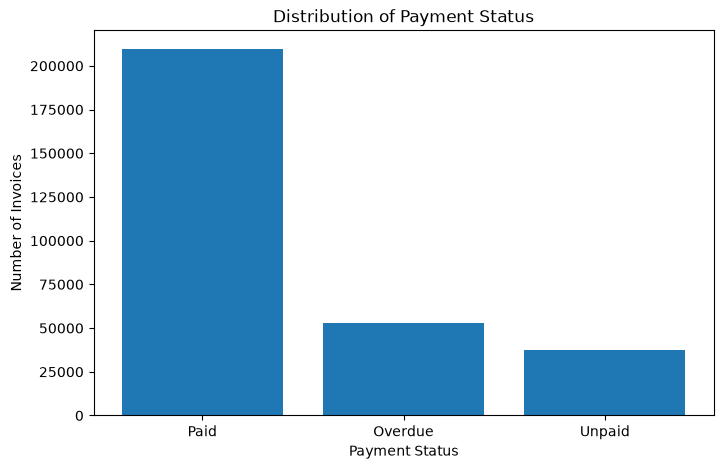

In [17]:
status_summary = (
    df.groupby("payment_status")
    .agg(
        invoice_count=("invoice_id", "count"),
        total_amount=("total_amount", "sum")
    )
)
status_summary["invoice_pct"] = status_summary["invoice_count"] / len(df) * 100
status_summary["amount_pct"] = status_summary["total_amount"] / df["total_amount"].sum() * 100
display(status_summary)

plt.figure(figsize=(8,5))
order = ["Paid", "Overdue", "Unpaid"]
counts = df["payment_status"].value_counts().reindex(order, fill_value=0)
plt.bar(counts.index, counts.values)
plt.title("Distribution of Payment Status")
plt.xlabel("Payment Status")
plt.ylabel("Number of Invoices")
plt.show()

### Interpretasi

Distribusi menunjukkan **209.722 invoice Paid, 52.754 Overdue, dan 37.524 Unpaid**. Jika dilihat dari nominal, total outstanding (Unpaid + Overdue) mencapai sekitar **Rp117,26 miliar**. Ini menunjukkan bahwa masalah pembayaran perlu dilihat bukan hanya dari jumlah invoice, tetapi juga dari nilai rupiahnya.



## 2. Vacant vs Payment Status

**Pertanyaan:** Apakah status pembayaran berbeda antara unit yang vacant dan non-vacant?

Perbandingan ini membantu mengevaluasi apakah kondisi kekosongan unit berkaitan dengan pola pembayaran. Uji Chi-Square dan Cramer's V digunakan sebagai pelengkap deskriptif, bukan sebagai bukti sebab-akibat.


### EDA — Vacant vs Payment Status

Crosstab digunakan untuk melihat komposisi status pembayaran pada unit vacant dan non-vacant. Setelah deskriptif, uji Chi-Square digunakan untuk menguji ada/tidaknya asosiasi, sedangkan Cramer's V membantu melihat kekuatan asosiasi tersebut.


payment_status,Overdue,Paid,Unpaid
is_vacant,,,
False,10.13,79.82,10.05
True,40.15,39.90,19.95


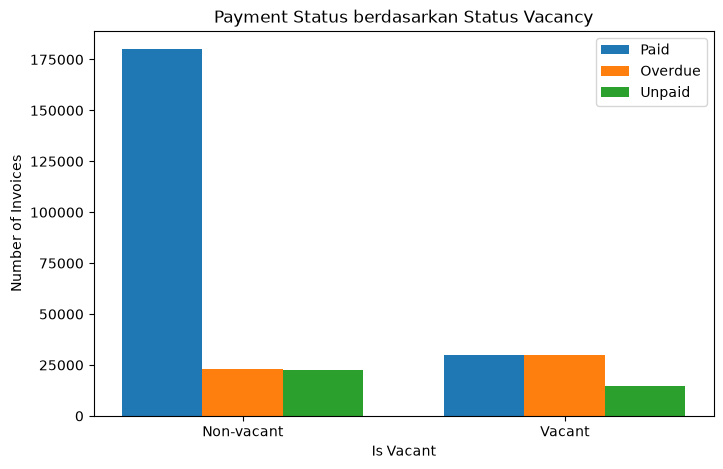

In [18]:
vacant_status = pd.crosstab(
    df["is_vacant"],
    df["payment_status"],
    normalize="index"
) * 100

display(vacant_status)

plt.figure(figsize=(8,5))
ct = pd.crosstab(df["is_vacant"], df["payment_status"]).reindex(
    index=[False, True], columns=["Paid", "Overdue", "Unpaid"], fill_value=0
)
x = np.arange(len(ct.index))
width = 0.25
for i, status in enumerate(ct.columns):
    plt.bar(x + (i-1)*width, ct[status].values, width, label=status)
plt.xticks(x, ["Non-vacant", "Vacant"])
plt.title("Payment Status berdasarkan Status Vacancy")
plt.xlabel("Is Vacant")
plt.ylabel("Number of Invoices")
plt.legend()
plt.show()

### Interpretasi

Secara deskriptif, unit vacant memiliki proporsi `Overdue` yang lebih tinggi dibanding unit non-vacant. Uji Chi-Square juga menunjukkan adanya asosiasi yang sangat kuat secara statistik antara status vacant dan payment status pada dataset ini (p-value < 0,05; Cramer's V ≈ 0,391).

Hasil ini menunjukkan **asosiasi**, bukan bukti bahwa vacancy menyebabkan tunggakan. Faktor penyebab tidak dapat disimpulkan hanya dari uji ini.



Dari EDA ini kita dapat melihat apakah komposisi `Overdue` dan `Unpaid` berbeda antara unit vacant dan non-vacant. Perbandingan berikutnya akan menggunakan uji statistik untuk mengecek apakah hubungan tersebut signifikan secara statistik.

In [19]:
contingency = pd.crosstab(df["is_vacant"], df["payment_status"])
chi2, p_value, dof, expected = chi2_contingency(contingency)

n = contingency.to_numpy().sum()
min_dim = min(contingency.shape) - 1
cramers_v = np.sqrt((chi2 / n) / min_dim)

print(f"Chi-square statistic : {chi2:,.2f}")
print(f"p-value              : {p_value:.6g}")
print(f"Cramer's V           : {cramers_v:.4f}")

Chi-square statistic : 45,854.99
p-value              : 0
Cramer's V           : 0.3910


**Interpretasi:** p-value digunakan untuk menilai apakah terdapat bukti statistik adanya hubungan antara status vacant dan payment status. `Cramer's V` digunakan sebagai ukuran kekuatan asosiasi. Hasil statistik ini tidak berarti vacancy menyebabkan tunggakan; analisis ini hanya menunjukkan hubungan pada dataset.

## 3. Analisis Township

**Pertanyaan:** Township mana yang memiliki rasio tunggakan dan nilai outstanding paling tinggi?

Rasio digunakan agar township dengan jumlah invoice berbeda tetap dapat dibandingkan secara lebih adil, sementara nilai outstanding menunjukkan besarnya nominal yang perlu diperhatikan.


### EDA — Township

Agregasi dilakukan pada level township untuk membandingkan jumlah invoice, nominal outstanding, dan rasio tunggakan. Rasio memberikan ukuran relatif, sedangkan outstanding menunjukkan skala nominal.


In [20]:
township_summary = (
    df.groupby("township_name")
    .agg(
        invoices=("invoice_id", "count"),
        total_billed=("total_amount", "sum"),
        overdue=("payment_status", lambda s: (s == "Overdue").sum()),
        unpaid=("payment_status", lambda s: (s == "Unpaid").sum()),
        paid=("payment_status", lambda s: (s == "Paid").sum()),
        outstanding=("outstanding_amount", "sum")
    )
)

township_summary["arrears_ratio"] = (
    (township_summary["overdue"] + township_summary["unpaid"])
    / township_summary["invoices"]
)

township_summary["outstanding_pct_of_billed"] = (
    township_summary["outstanding"]
    / township_summary["total_billed"]
)

display(
    township_summary
    .sort_values("arrears_ratio", ascending=False)
    .style.format({
        "total_billed": "Rp {:,.0f}",
        "outstanding": "Rp {:,.0f}",
        "arrears_ratio": "{:.2%}",
        "outstanding_pct_of_billed": "{:.2%}"
    })
)

,invoices,total_billed,overdue,unpaid,paid,outstanding,arrears_ratio,outstanding_pct_of_billed
township_name,,,,,,,,
NavaPark,12445,"Rp 16,814,897,500",2211,1576,8658,"Rp 4,843,682,500",30.43%,28.81%
Kota Wisata,74662,"Rp 99,888,847,500",13109,9556,51997,"Rp 29,870,235,000",30.36%,29.90%
Deltamas,41356,"Rp 53,875,717,500",7297,5152,28907,"Rp 15,349,810,000",30.10%,28.49%
Grand Wisata,71729,"Rp 94,818,370,000",12719,8850,50160,"Rp 28,150,727,500",30.07%,29.69%
BSD City,99808,"Rp 135,381,255,000",17418,12390,70000,"Rp 39,044,755,000",29.87%,28.84%


### Interpretasi

Berdasarkan data, **NavaPark** memiliki arrears ratio tertinggi sekitar **30,43%**, sedangkan **BSD City** memiliki nominal outstanding sekitar **Rp39,04 miliar**. Karena rasio dan nominal dapat menunjuk pada township yang berbeda, keduanya perlu dibaca bersama saat menentukan fokus collection.



### Visualisasi Arrears Ratio Township


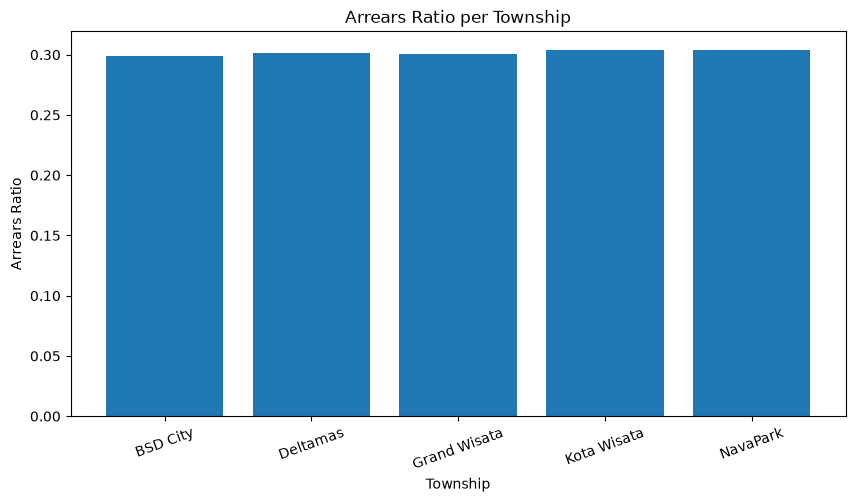

In [21]:
plt.figure(figsize=(10,5))
plot_df = township_summary.reset_index()
plt.bar(plot_df["township_name"], plot_df["arrears_ratio"])
plt.title("Arrears Ratio per Township")
plt.xlabel("Township")
plt.ylabel("Arrears Ratio")
plt.xticks(rotation=20)
plt.show()

## 4. Analisis Cluster

**Pertanyaan:** Cluster mana yang paling menonjol dalam masalah tunggakan?

Analisis pada level cluster dibuat lebih granular dibanding township sehingga dapat membantu menentukan area yang lebih spesifik untuk prioritas collection.


### EDA — Cluster

Setelah melihat gambaran township, analisis diturunkan ke level cluster untuk menemukan lokasi yang lebih spesifik. Top cluster ditampilkan berdasarkan rasio tunggakan dan nominal outstanding sebagai konteks prioritas operasional.


In [22]:
cluster_summary = (
    df.groupby(["township_name", "cluster_id", "cluster_category"])
    .agg(
        invoices=("invoice_id", "count"),
        outstanding=("outstanding_amount", "sum"),
        arrears=("is_arrears", "sum")
    )
)

cluster_summary["arrears_ratio"] = (
    cluster_summary["arrears"] / cluster_summary["invoices"]
)

display(
    cluster_summary
    .sort_values(["arrears_ratio", "outstanding"], ascending=False)
    .head(15)
)

invoices      outstanding  \
township_name cluster_id  cluster_category                                 
Kota Wisata   CLS-SML-067 Middle Residential       3111 1,298,265,000.00   
              CLS-SML-097 Middle Residential       2872 1,226,710,000.00   
Deltamas      CLS-SML-025 Middle Residential       2963 1,330,317,500.00   
Kota Wisata   CLS-SML-053 Commercial Ruko          2800 1,116,657,500.00   
BSD City      CLS-SML-069 Middle Residential       3115 1,040,077,500.00   
Kota Wisata   CLS-SML-048 Middle Residential       3129 1,141,720,000.00   
              CLS-SML-096 Premium Residential      2705 1,175,672,500.00   
Grand Wisata  CLS-SML-060 Middle Residential       2891 1,237,130,000.00   
BSD City      CLS-SML-027 Middle Residential       3158 1,441,757,500.00   
              CLS-SML-024 Middle Residential       2680   986,052,500.00   
Grand Wisata  CLS-SML-057 Commercial Ruko          3085 1,463,287,500.00   
Kota Wisata   CLS-SML-073 Premium Residential      3201 1,307,125,000.00   
Deltamas      CLS-SML-056 Middle Residential       2921 1,225,902,500.00   
BSD City      CLS-SML-018 Middle Residential       3268 1,256,320,000.00   
              CLS-SML-066 Middle Residential       3127 1,477,230,000.00   

                                               arrears  arrears_ratio  
township_name cluster_id  cluster_category                             
Kota Wisata   CLS-SML-067 Middle Residential      1061           0.34  
              CLS-SML-097 Middle Residential       940           0.33  
Deltamas      CLS-SML-025 Middle Residential       969           0.33  
Kota Wisata   CLS-SML-053 Commercial Ruko          911           0.33  
BSD City      CLS-SML-069 Middle Residential      1011           0.32  
Kota Wisata   CLS-SML-048 Middle Residential      1015           0.32  
              CLS-SML-096 Premium Residential      872           0.32  
Grand Wisata  CLS-SML-060 Middle Residential       930           0.32  
BSD City      CLS-SML-027 Middle Residential      1011           0.32  
              CLS-SML-024 Middle Residential       854           0.32  
Grand Wisata  CLS-SML-057 Commercial Ruko          983           0.32  
Kota Wisata   CLS-SML-073 Premium Residential     1018           0.32  
Deltamas      CLS-SML-056 Middle Residential       925           0.32  
BSD City      CLS-SML-018 Middle Residential      1034           0.32  
              CLS-SML-066 Middle Residential       989           0.32

### Interpretasi

Pada level cluster, beberapa cluster menunjukkan arrears ratio di atas rata-rata keseluruhan. Contoh tertinggi pada hasil ini adalah **CLS-SML-067 di Kota Wisata** dengan arrears ratio sekitar **34%**. Angka tersebut menunjukkan area yang layak diprioritaskan untuk investigasi collection, tetapi belum menjelaskan penyebab tunggakan.



## 5. Payment Method

**Pertanyaan:** Bagaimana distribusi metode pembayaran setelah standardisasi?

Analisis ini digunakan untuk melihat apakah data payment method sudah cukup konsisten dan kategori mana yang paling banyak digunakan. Missing value tetap ditampilkan karena missingness sendiri merupakan temuan kualitas data.


### Visualisasi Payment Method setelah standarisasi

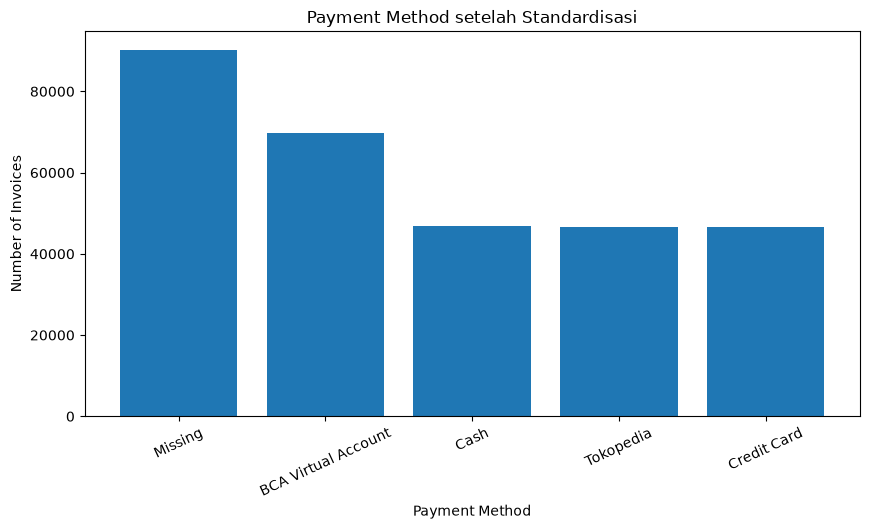

In [23]:
plt.figure(figsize=(10,5))
plot_df = df["payment_method_clean"].value_counts(dropna=False)
labels = plot_df.index.astype("string").fillna("Missing")
plt.bar(labels, plot_df.values)
plt.title("Payment Method setelah Standardisasi")
plt.xlabel("Payment Method")
plt.ylabel("Number of Invoices")
plt.xticks(rotation=25)
plt.show()

## 6. Missing Contact Number

**Pertanyaan:** Seberapa besar proporsi owner/unit yang tidak memiliki nomor kontak?

Informasi kontak penting dalam proses collection. Karena itu, persentase missing tidak hanya dilihat secara keseluruhan tetapi juga dibandingkan antar township untuk mengetahui apakah masalah terkonsentrasi pada area tertentu.


### EDA — Kelengkapan Contact Number

Kita menghitung jumlah dan persentase unit yang tidak memiliki nomor kontak. Angka ini menggambarkan kesiapan data untuk mendukung proses collection.


In [24]:
contact_missing = units["contact_number"].isna().sum()
contact_missing_pct = contact_missing / len(units) * 100

print(f"Missing contact number : {contact_missing:,}")
print(f"Persentase             : {contact_missing_pct:.2f}%")

Missing contact number : 5,000
Persentase             : 20.00%


### Interpretasi

Terdapat **5.000 unit atau 20,00%** yang tidak memiliki contact number. Ini merupakan temuan kualitas data yang relevan terhadap proses collection karena sebagian owner tidak memiliki informasi kontak yang dapat langsung digunakan.



### Missing Contact per Township

Persentase missing dibandingkan antar township untuk melihat apakah masalah kualitas data terkonsentrasi pada area tertentu. Ini membantu menentukan apakah perbaikan data dapat dilakukan secara umum atau perlu difokuskan pada wilayah tertentu.


In [25]:
contact_by_township = (
    units.merge(clusters, on="cluster_id", how="left")
    .groupby("township_name")
    .agg(
        units=("unit_id", "count"),
        missing_contact=("contact_number", lambda s: s.isna().sum())
    )
)
contact_by_township["missing_pct"] = (
    contact_by_township["missing_contact"] / contact_by_township["units"] * 100
)

display(contact_by_township.sort_values("missing_pct", ascending=False))

,units,missing_contact,missing_pct
township_name,,,
Kota Wisata,6238,1297,20.79
NavaPark,1014,208,20.51
Deltamas,3470,708,20.40
BSD City,8298,1635,19.70
Grand Wisata,5980,1152,19.26


## 7. Outstanding Billing

**Pertanyaan:** Berapa nilai tagihan yang masih outstanding?

Outstanding didefinisikan pada business case sebagai invoice berstatus `Unpaid` atau `Overdue`. Nilai ini memberikan estimasi nominal yang masih perlu ditagih atau ditindaklanjuti.


### EDA — Outstanding Billing

Outstanding dihitung dari invoice `Unpaid` dan `Overdue`. Selain jumlah invoice, kita menjumlahkan `total_amount` agar manajemen dapat melihat besarnya nominal yang masih terbuka.


In [26]:
outstanding_summary = (
    df.groupby("payment_status")
    .agg(
        invoice_count=("invoice_id", "count"),
        outstanding=("outstanding_amount", "sum")
    )
)

display(outstanding_summary)

print(
    "Total outstanding (Unpaid + Overdue): "
    f"Rp {df['outstanding_amount'].sum():,.0f}"
)

,invoice_count,outstanding
payment_status,,
Overdue,52754,"68,100,527,500.00"
Paid,209722,0.00
Unpaid,37524,"49,158,682,500.00"


Total outstanding (Unpaid + Overdue): Rp 117,259,210,000


### Interpretasi

Total outstanding dari invoice `Unpaid` dan `Overdue` adalah sekitar **Rp117,26 miliar**. Angka ini merupakan estimasi nominal tagihan yang masih terbuka dalam dataset, sehingga dapat digunakan sebagai dasar untuk analisis aging dan prioritas penagihan.



## 8. Tunggakan Berkelanjutan > 6 Bulan

**Pertanyaan:** Berapa streak dan unit yang mengalami tunggakan lebih dari enam bulan berturut-turut?

Streak dihitung berdasarkan bulan kalender untuk unit yang sama. Fokusnya adalah mencari tunggakan yang bersifat berkelanjutan, karena kasus seperti ini lebih relevan untuk strategi collection berbasis aging.


### EDA — Tunggakan Berkelanjutan

Kita membentuk urutan bulan untuk setiap unit, lalu mencari rangkaian bulan berturut-turut ketika status berada pada `Unpaid` atau `Overdue`. Satu bulan dihitung maksimal satu kali per unit agar beberapa invoice pada bulan yang sama tidak dihitung sebagai beberapa bulan. Hanya streak **lebih dari enam bulan** yang masuk ke hasil akhir.

Pendekatan ini berbeda dari sekadar menghitung total invoice overdue karena mempertimbangkan **kontinuitas waktu**.


In [33]:
# Analisis chronic arrears: lebih dari 6 bulan berturut-turut
# Satu unit hanya dihitung satu kali untuk setiap bulan billing.
# Jika dalam satu bulan ada minimal satu invoice Unpaid/Overdue,
# maka bulan tersebut dianggap sebagai bulan tunggakan.

streak_base = (
    df[
        ["unit_id", "billing_date", "payment_status", "total_amount"]
    ]
    .copy()
)

# Tandai invoice yang masih outstanding
streak_base["non_paid"] = streak_base["payment_status"].isin(
    ["Unpaid", "Overdue"]
)

# Nilai outstanding hanya untuk invoice yang masih belum lunas
streak_base["outstanding_amount"] = streak_base["total_amount"].where(
    streak_base["non_paid"], 0
)

# Agregasi ke level unit-bulan
# Satu bulan hanya dihitung sekali dalam streak
monthly_arrears = (
    streak_base
    .groupby(["unit_id", "billing_date"], as_index=False)
    .agg(
        non_paid=("non_paid", "any"),
        outstanding=("outstanding_amount", "sum")
    )
    .sort_values(["unit_id", "billing_date"])
)

# Buat nomor bulan agar kontinuitas kalender dapat dicek
monthly_arrears["month_num"] = (
    monthly_arrears["billing_date"].dt.year * 12
    + monthly_arrears["billing_date"].dt.month
)

# Bulan sebelumnya untuk unit yang sama
monthly_arrears["prev_month_num"] = (
    monthly_arrears.groupby("unit_id")["month_num"].shift()
)

# Tentukan awal streak baru
monthly_arrears["new_group"] = (
    (~monthly_arrears["non_paid"])
    | monthly_arrears["prev_month_num"].isna()
    | (
        monthly_arrears["month_num"]
        - monthly_arrears["prev_month_num"]
        != 1
    )
)

# Buat ID kelompok streak
monthly_arrears["group"] = (
    monthly_arrears.groupby("unit_id")["new_group"].cumsum()
)

# Ringkas setiap streak tunggakan
streaks = (
    monthly_arrears[monthly_arrears["non_paid"]]
    .groupby(["unit_id", "group"])
    .agg(
        start_month=("billing_date", "min"),
        end_month=("billing_date", "max"),
        months=("billing_date", "size"),
        outstanding=("outstanding", "sum")
    )
    .reset_index()
)

# Lebih dari 6 bulan = minimal 7 bulan berturut-turut
long_streak = streaks[streaks["months"] > 6].copy()

print(f"Streak > 6 bulan    : {len(long_streak):,}")
print(f"Jumlah unit terlibat: {long_streak['unit_id'].nunique():,}")
print(f"Outstanding         : Rp {long_streak['outstanding'].sum():,.0f}")

display(
    long_streak[["start_month", "end_month", "months", "outstanding"]]
    .sort_values(["months", "outstanding"], ascending=False)
    .head(20)
)

Streak > 6 bulan    : 6
Jumlah unit terlibat: 6
Outstanding         : Rp 117,882,500


,unit_id,group,start_month,end_month,months,outstanding
31497,UNT-11607,6,2024-01-01,2024-07-01,7,"79,967,500.00"
62455,UNT-22923,4,2023-08-01,2024-02-01,7,"9,190,000.00"
39315,UNT-14480,6,2023-10-01,2024-04-01,7,"8,895,000.00"
62551,UNT-22959,1,2023-05-01,2023-11-01,7,"8,617,500.00"
23450,UNT-08665,2,2023-07-01,2024-01-01,7,"6,767,500.00"
57505,UNT-21104,1,2023-03-01,2023-09-01,7,"4,445,000.00"


### Interpretasi

Ditemukan **6 streak** tunggakan yang berlangsung lebih dari enam bulan, melibatkan **6 unit**, dengan total outstanding sekitar **Rp117,88 juta**. Seluruh streak yang teridentifikasi berlangsung selama **7 bulan**. Temuan ini menunjukkan bahwa tunggakan kronis memang ada, tetapi jumlah unit yang memenuhi kriteria relatif terbatas dibandingkan total invoice outstanding. Oleh karena itu, strategi collection sebaiknya tetap mempertimbangkan kombinasi aging, nominal outstanding, dan lokasi.



## 9. Anomali Pembayaran sebelum Handover

**Pertanyaan:** Seberapa banyak invoice `Paid` yang memiliki tanggal pembayaran sebelum handover?

Temuan ini diperlakukan sebagai **data-quality/business-rule anomaly**, bukan langsung dianggap sebagai fraud. Tujuan analisis adalah memberikan daftar kasus yang perlu direkonsiliasi dengan sistem atau dokumen transaksi.


### EDA — Pre-Handover Payment

Kasus `Paid` dengan `payment_date < handover_date` diringkas berdasarkan township. Tujuannya bukan menyimpulkan kesalahan transaksi secara otomatis, tetapi menunjukkan area yang memiliki lebih banyak kasus untuk proses rekonsiliasi.


In [28]:
logical_summary = (
    logical_error.groupby("township_name")
    .agg(
        anomaly_count=("invoice_id", "count"),
        anomaly_amount=("total_amount", "sum")
    )
    .sort_values("anomaly_count", ascending=False)
)

display(logical_summary)

print(f"Total anomaly invoices : {len(logical_error):,}")
print(f"Total anomaly amount   : Rp {logical_error['total_amount'].sum():,.0f}")

,anomaly_count,anomaly_amount
township_name,,
BSD City,2107,"3,042,252,500.00"
Kota Wisata,1568,"1,975,260,000.00"
Grand Wisata,1538,"1,820,950,000.00"
Deltamas,847,"1,133,082,500.00"
NavaPark,231,"379,725,000.00"


Total anomaly invoices : 6,291
Total anomaly amount   : Rp 8,351,270,000


### Interpretasi

Terdapat **6.291 invoice Paid** yang tercatat memiliki payment date sebelum handover date. Kasus ini diperlakukan sebagai **anomali data/business rule** yang perlu direkonsiliasi dengan sumber transaksi atau sistem ERP; bukan langsung dianggap sebagai fraud.



## 10. Anomali Water Usage

**Pertanyaan:** Berapa banyak billing yang memiliki penggunaan air tidak wajar?

Nilai negatif merupakan anomali logika, sedangkan outlier IQR merupakan anomali statistik. Keduanya dibedakan agar tim dapat menentukan apakah masalah berasal dari input data, meter, atau proses billing.


### EDA — Water Usage Anomalies

Anomali air diringkas berdasarkan tiga rule: nilai negatif, outlier IQR, dan nilai ekstrem ≥ 1.000 m³. Pengelompokan ini membantu membedakan masalah statistik umum dari kasus yang secara bisnis terlihat sangat ekstrem.


In [29]:
water_anomaly_summary = pd.DataFrame({
    "Anomaly Type": [
        "Negative water usage",
        "IQR outlier (> upper bound)",
        "Extreme value >= 1,000 m3"
    ],
    "Count": [
        df["water_negative"].sum(),
        df["water_iqr_outlier"].sum(),
        (df["water_usage_m3"] >= 1000).sum()
    ]
})

water_anomaly_summary["Percentage"] = water_anomaly_summary["Count"] / len(df) * 100
display(water_anomaly_summary)

,Anomaly Type,Count,Percentage
0,Negative water usage,1519,0.51
1,IQR outlier (> upper bound),1481,0.49
2,"Extreme value >= 1,000 m3",1481,0.49


### Interpretasi

Ditemukan **1.519 nilai water usage negatif** dan **1.481 outlier berdasarkan IQR**. Selain itu, terdapat nilai penggunaan air yang sangat ekstrem. Temuan ini perlu ditindaklanjuti sebagai isu kualitas data atau sistem meter/billing karena dapat memengaruhi tagihan dan analisis konsumsi.



### Visualisasi Distribusi Water Usage


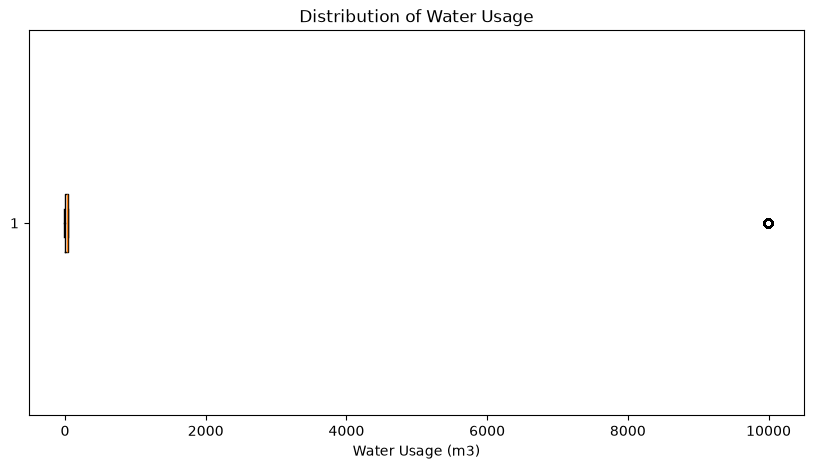

In [30]:
plt.figure(figsize=(10,5))
plt.boxplot(df["water_usage_m3"].dropna(), vert=False)
plt.title("Distribution of Water Usage")
plt.xlabel("Water Usage (m3)")
plt.show()

### Visualisasi Distribusi Water Usage without Extreme Outlier

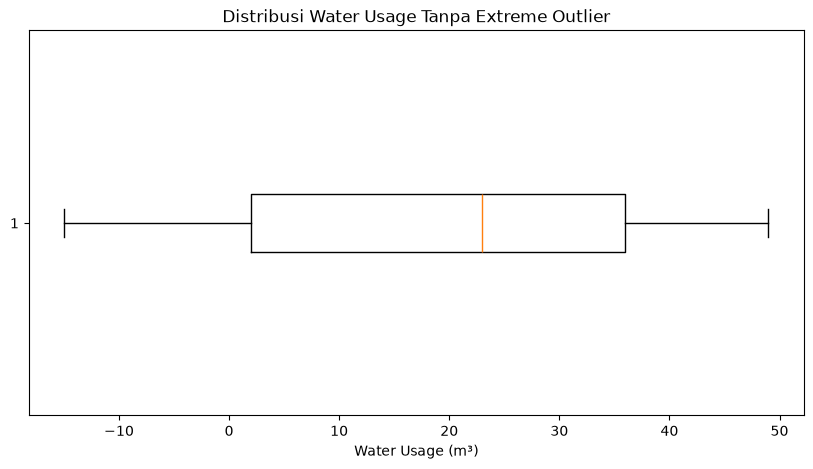

In [31]:
plt.figure(figsize=(10,5))

water_usage = df["water_usage_m3"].dropna()

plt.boxplot(water_usage, vert=False, showfliers=False)

plt.title("Distribusi Water Usage Tanpa Extreme Outlier")
plt.xlabel("Water Usage (m³)")

plt.show()

# Kesimpulan dan Rekomendasi

## Temuan Utama

1. **Payment status:** dataset menunjukkan tiga status utama, yaitu `Paid`, `Overdue`, dan `Unpaid`. Outstanding billing dihitung sebagai total nilai invoice yang belum berstatus `Paid`.
2. **Vacancy:** distribusi payment status dibandingkan antara unit vacant dan non-vacant. Uji chi-square dan Cramer's V digunakan untuk mengukur hubungan statistiknya.
3. **Township/cluster:** arrears ratio dan outstanding amount dihitung per township dan cluster agar area dengan beban tunggakan dapat ditelusuri.
4. **Payment method:** beberapa label seperti `toped`, `Tokopedia`, `bca va`, `VA BCA`, dan `BCA Virtual Account` merepresentasikan metode yang sama sehingga perlu distandardisasi.
5. **Contact number:** missing contact number diperlakukan sebagai data quality issue karena dapat menghambat proses collection.
6. **Logical error:** invoice `Paid` dengan `payment_date < handover_date` ditandai sebagai anomaly dan tidak dihapus karena memiliki nilai diagnostik untuk sistem billing.
7. **Water usage:** nilai negatif dan nilai ekstrem ditandai sebagai anomaly. Nilai ekstrem tidak otomatis dihapus karena dapat menjadi indikasi salah input meteran.
8. **Continuous arrears:** streak lebih dari 6 bulan dihitung berdasarkan bulan kalender yang muncul secara berturut-turut pada unit yang sama.

## Rekomendasi Operasional

- Membuat monitoring **arrears ratio dan outstanding amount** pada level township dan cluster.
- Memprioritaskan proses collection berdasarkan umur dan nilai outstanding, bukan hanya jumlah invoice.
- Menerapkan master/reference table untuk `payment_method` agar variasi input tidak muncul kembali.
- Menjadikan `contact_number` sebagai field yang divalidasi pada proses pembaruan data pelanggan.
- Menambahkan validasi sistem agar `payment_date` tidak dapat tercatat sebelum `handover_date` tanpa status pengecualian yang terdokumentasi.
- Menambahkan validasi meteran, misalnya flag untuk nilai negatif dan lonjakan pemakaian ekstrem sebelum invoice diterbitkan.
- Menggunakan hasil analisis ini sebagai dasar dashboard monitoring Estate Management.
